# Data analysis and processing

We're going to re-analyse the data from the paper [Compact, low-threshold squeezed light source](https://opg.optica.org/abstract.cfm?uri=oe-27-26-37877), as well as data taken during the project that led to the paper [Distributed quantum sensing in a continuous-variable entangled network](https://www.nature.com/articles/s41567-019-0743-x).

Both of these papers are about [squeezed light](https://wikipedia.org/en/Squeezed_states_of_light) generated by an [optical parametric oscillator (OPO)](https://omni.wikiwand.com/en/articles/Optical_parametric_oscillator). In the textbook description of squeezed vacuum, the variance of the squeezed quadrature (let's say it's $\hat x$) is $\text{Var}(x) = e^{-2r}$ and for the anti-squeezed quadrature ($\hat p$) it is $\text{Var}(p) = e^{2r}$. Here, $r$ is the _squeezing parameter_. For a realistic state, the situation is more complex - $r$ is not well-defined in the experiment, but the variance will instead depend on losses, the frequency that it is observed at, etc.

Denoting by $V_+$ the variance of the anti-squeezing relative to shotnoise (the standard noise level, whose value depends on the definition of the quadrature operators), and by $V_-$ the squeezing variance, the simplest formula for the squeezing of an OPO is for the case of no losses and at DC (i.e. frequency = zero):

$V_\pm = 1 \pm \frac{4x}{(1\mp x)^2},$

where $x=\sqrt{P/P_{th}}$ is the _pump parameter_ given by the power $P$ of the field used for pumping the nonlinear interaction inside the OPO relative to a _threshold power_ $P_{th}$.

For non-zero losses, we have the _overall efficiency_ $\eta = 1-\text{losses}$, and we also introduce the _OPO half-width-half-max bandwidth_ $f_{HWHM}$ and the frequency of observation $f$. Then the expression above becomes

$V_\pm = 1 \pm \frac{4x\eta}{(1\mp x)^2 + (f/f_{HWHM})^2}.$

The variance of a general quadrature $x_\theta$ at an angle $\theta$ with the squeezed quadrature can be obtained by

$V(\theta) = V_-\cos^2\theta + V_+\sin^2\theta$.

Finally, if there is some fluctuation in the observed phase, this can be incorporated by modeling it as a normal distribution around the phase set point with standard deviation $\sigma$, resulting in a variance

$V(\theta) = \frac{1}{2} V_- (1+\cos(2\theta)e^{-2\sigma^2}) + \frac{1}{2} V_+ (1-\cos(2\theta)e^{-2\sigma^2}) .$

#### Data loading and processing

The data for the first paper (the "Jens" paper) has been acquired by a Keysight N9000A signal analyzer. It is in CSV format which is easy to import e.g. with NumPy's `genfromtxt` function.

The data for the second paper (the "Xueshi" paper) has been acquired by a LeCroy HDO6034 oscilloscope. This is in a proprietary binary format, so here we need some custom code to import it. This is available in the `lecroy.py` file.

A better way to store large amounts of data is in the commonly used [HDF5 binary data format](https://omni.wikiwand.com/en/articles/Hierarchical_Data_Format). In Python, this can be used via the [h5py](https://www.h5py.org) package.

We will also look at processing the data. For calculating spectra, filtering time series, etc., we will use tools from `scipy.signal` and `scipy.fft`. For fitting data to theoretical models, we will use tools from `scipy.optimize`.

In [164]:
# Importing libraries
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import lecroy
import h5py
import os
import sys
from scipy.signal import periodogram, welch
from scipy.fft import rfft, irfft, rfftfreq
from scipy.optimize import curve_fit, least_squares
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
# Global plot style settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",            # Use Computer Modern for math
    "font.size": 14,                     # Base font size
    "axes.labelsize": 16,                # Axis label font size
    "axes.titlesize": 16,                # Title font size
    "legend.fontsize": 13,               # Legend font size
    "xtick.labelsize": 13,               # X tick label size
    "ytick.labelsize": 13,               # Y tick label size
    "axes.linewidth": 1.2,               # Thicker axis lines
    "xtick.direction": "in",             # x-yick direction
    "ytick.direction": "in",             # y-tick direction
    #"xtick.top": True,                   # Ticks on top
    #"ytick.right": True,                 # Ticks on right
    "text.usetex": False,                # Enable LaTeX if needed
    "figure.dpi": 150,                   # Good resolution for screens
    "savefig.dpi": 300                   # High resolution for saving
})

In [165]:
# Define function for nice plotting
def PlotSettings(ax, gridlines=False, minimalist=False):
    # Minimalist style
    if minimalist:
        # Hide top and right spines (borders)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        # Ticks only on bottom and left
        ax.tick_params(which='both', top=False, right=False)
    else:
        # Minor ticks
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        # Tick parameters
        ax.tick_params(which='both', direction='in', top=True, right=True)
        ax.tick_params(which='major', length=7, width=1.2)
        ax.tick_params(which='minor', length=4, width=1)
    # Optional grid
    if gridlines:
        ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
        ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.4)

In [166]:
jens_folder = '../../squeezing_data/jens' # Path to Jens' data folder
jens_files = os.listdir(jens_folder)
xueshi_folder = '../../squeezing_data/xueshi' # Path to Xueshi's data folder
xueshi_files = os.listdir(xueshi_folder)

In [167]:
# Defining functions for converting from linear to dB scale and vice versa
def lin2db(lin):
    """
    Convert linear power to decibel scale.
    Input: linear power (numpy array)
    Output: decibel power (numpy array)
    """
    # Avoid log10(0)
    lin = np.clip(lin, 1e-10, None)
    return 10 * np.log10(lin)
def db2lin(db):
    """
    Convert decibel power to linear scale.
    Input: decibel power (numpy array)
    Output: linear power (numpy array)
    """
    # Avoid exp(large) overflow
    db = np.clip(db, -np.inf, 1e10)
    return 10**(db/10)

In [168]:
# Defining functions for the squeezed states
Vsq = lambda x, eta, frel: 1 - 4*eta*x / ((1+x)**2 + frel**2)
Vasq = lambda x, eta, frel: 1 + 4*eta*x / ((1-x)**2 + frel**2)
Vrot = lambda x, eta, frel, theta: np.cos(theta*np.pi/180)**2 * Vsq(x, eta, frel) + np.sin(theta*np.pi/180)**2 * Vasq(x, eta, frel)
# Defining the fluctuation functions
def Vrotfluct(x, eta, frel, theta, sigma_x=0, sigma_p=None):
    if sigma_p is None:
        sigma_p = sigma_x
    
    Vx = .5 * Vsq(x, eta, frel) * (1 + np.cos(2 * theta * np.pi/180) * np.exp(-2 * (sigma_x * np.pi/180)**2))
    Vp = .5 * Vasq(x, eta, frel) * (1 - np.cos(2 * theta * np.pi/180) * np.exp(-2 * (sigma_p * np.pi/180)**2))

    return Vx + Vp

## Jens data

In [169]:
# Print list of files in Jen's folder
print("Files in Jen's folder:")
for file in jens_files:
    print(file)

Files in Jen's folder:
.ipynb_checkpoints
5MHz_0.5_A.csv
5MHz_0.5_S.csv
5MHz_1.1_A.csv
5MHz_1.1_S.csv
5MHz_1.4_A.csv
5MHz_1.4_S.csv
5MHz_1.9_A.csv
5MHz_1.9_S.csv
5MHz_2.4_A.csv
5MHz_2.4_S.csv
5MHz_2.9_A.csv
5MHz_2.9_S.csv
5MHz_3.4_A.csv
5MHz_3.4_S.csv
5MHz_3.6_A.csv
5MHz_3.6_S.csv
5MHz_4.3_A.csv
5MHz_4.3_S.csv
5MHz_4.7_A.csv
5MHz_4.7_S.csv
5MHz_elec.csv
5MHz_vac.csv
power_scaling.png
spectra.png
SPEC_1.3_A.csv
SPEC_1.3_S.csv
SPEC_2.5_A.csv
SPEC_2.5_S.csv
SPEC_3.4_A.csv
SPEC_3.4_S.csv
SPEC_elec.csv
SPEC_vac.csv


We select the files containing the spectrum:

In [170]:
# Extract file paths containing squeezing, anti-squeezing, electrical signals and vacuum
sq_spec_files = [os.path.join(jens_folder, f) for f in sorted(jens_files) if 'SPEC' in f and '_S' in f]
asq_spec_files = [os.path.join(jens_folder, f) for f in sorted(jens_files) if 'SPEC' in f and '_A' in f]
elec_spec_file = os.path.join(jens_folder, 'SPEC_elec.csv')
vac_spec_file = os.path.join(jens_folder, 'SPEC_vac.csv')
sq_spec_files, asq_spec_files

(['../../squeezing_data/jens\\SPEC_1.3_S.csv',
  '../../squeezing_data/jens\\SPEC_2.5_S.csv',
  '../../squeezing_data/jens\\SPEC_3.4_S.csv'],
 ['../../squeezing_data/jens\\SPEC_1.3_A.csv',
  '../../squeezing_data/jens\\SPEC_2.5_A.csv',
  '../../squeezing_data/jens\\SPEC_3.4_A.csv'])

Read data from the files. The first 45 lines of each file containt metadata, so we first look at these, but then skip them when reading the actual data.

In [171]:
# Reading metadata from electrical signal file
with open(elec_spec_file) as f:
    meta = [f.readline().strip().split(',') for i in range(45)]
for text in meta:
    if len(text) > 1:
        print(f'{text[0]:<25} : {text[1]}')
    else:
        print(text)

['Trace']
['Swept SA']
A.18.12                   : N9000A
503                       : 01
Segment                   : 0
Number of Points          : 5000
Sweep Time                : 0.889488733333
Start Frequency           : 1000000
Stop Frequency            : 120000000
Average Count             : 0
Average Type              : LogPower(Video)
RBW                       : 1100000
RBW Filter                : Gaussian
RBW Filter BW             : 3dB
VBW                       : 300
Sweep Type                : Swept
X Axis Scale              : Lin
PreAmp State              : Off
PreAmp Band               : Low
Trigger Source            : Free
Trigger Level             : 1.2
Trigger Slope             : Positive
Trigger Delay             : 0
Phase Noise Optimization  : Fast
Swept If Gain             : Low
FFT If Gain               : Autorange
RF Coupling               : AC
FFT Width                 : 411900
Ext Ref                   : 10000000
Input                     : RF
RF Calibrator        

In [172]:
# Read data from file paths avoiding the metadata on the first 45 lines
electronic = np.genfromtxt(elec_spec_file, delimiter=',', skip_header=45)
vacuum = np.genfromtxt(vac_spec_file, delimiter=',', skip_header=45)
squeezing = np.array([np.genfromtxt(f, delimiter=',', skip_header=45) for f in sq_spec_files])
antisqueezing = np.array([np.genfromtxt(f, delimiter=',', skip_header=45) for f in asq_spec_files])

In [173]:
# Printing shapes of data
electronic.shape, vacuum.shape, squeezing.shape, antisqueezing.shape

((5000, 2), (5000, 2), (3, 5000, 2), (3, 5000, 2))

In [174]:
# Convert frequency to MHz and extract the PSD values
f = electronic[:,0] / 1e6  # to MHz
electronic = electronic[:,1]
vacuum = vacuum[:,1]
squeezing = squeezing[:,:,1]
antisqueezing = antisqueezing[:,:,1]

As we saw from the "Y Axis Units" in the meta data, the spectrum is already given on a logarithmic scale. We also see this when plotting:

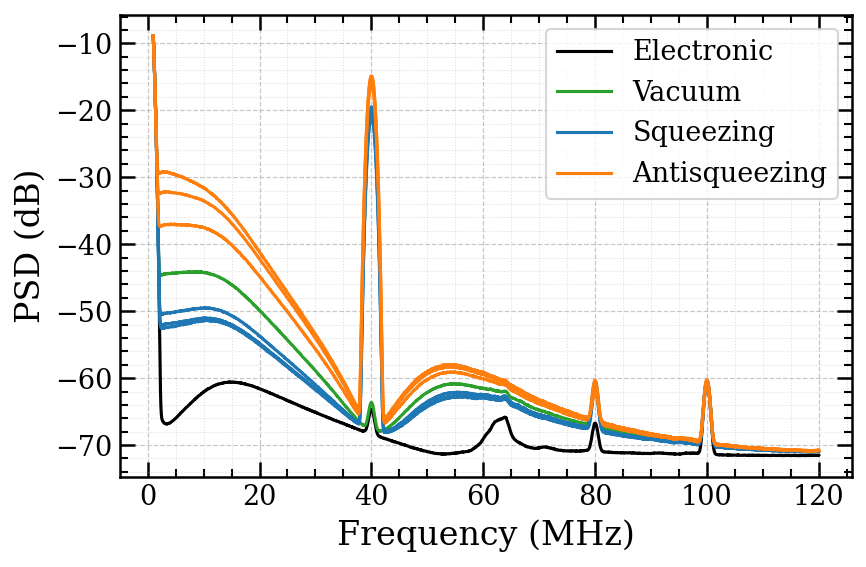

In [175]:
# Create the plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(f, electronic, c='k', label='Electronic')
ax.plot(f, vacuum, c='C2', label='Vacuum')
for sq in squeezing:
    ax.plot(f, sq, c='C0', label='Squeezing')
for asq in antisqueezing:
    ax.plot(f, asq, c='C1', label='Antisqueezing')
# Remove duplicate labels from legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
# Set x- and y-label
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('PSD (dB)')
# Initialize plot settings
PlotSettings(ax, gridlines=True)
# Adjust layout
plt.tight_layout()
# Show the plot
plt.show()

We are interested in the squeezing and antisqueezing noise variance _relative_ to the vacuum noise, so we normalise to this.
Before doing this, we can subtract the electronic noise which is common for all traces. When performing arithmetics on the spectra, we must first convert from logarithmic to linear scale:

In [176]:
vacuum_corr_lin = db2lin(vacuum) - db2lin(electronic)
squeezing_norm = lin2db((db2lin(squeezing) - db2lin(electronic)) / vacuum_corr_lin)
antisqueezing_norm = lin2db((db2lin(antisqueezing) - db2lin(electronic)) / vacuum_corr_lin)

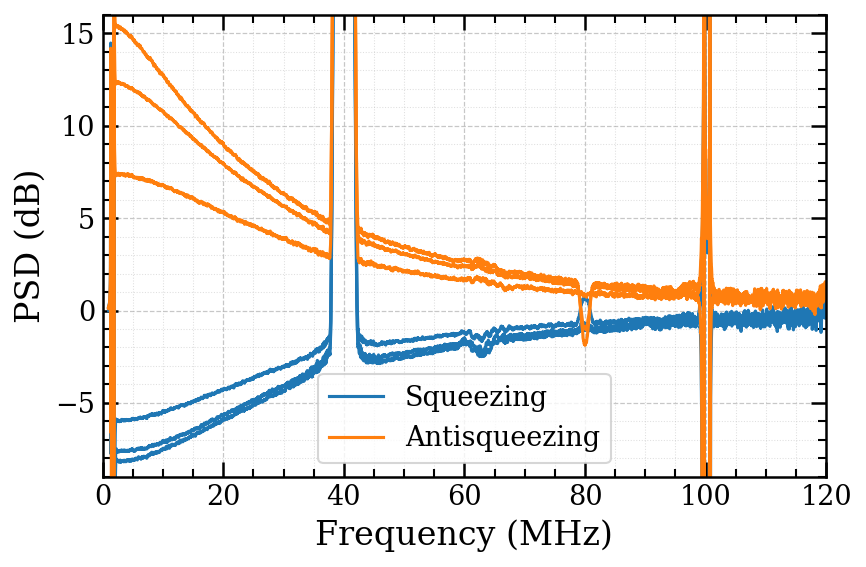

In [177]:
# Create the plot
fig, ax = plt.subplots(figsize=(6, 4))
# Plot data
for sq in squeezing_norm:
    ax.plot(f, sq, c='C0', label='Squeezing')
for asq in antisqueezing_norm:
    ax.plot(f, asq, c='C1', label='Antisqueezing')
# Remove duplicate labels from legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
# Set x- and y-limits
ax.set_xlim(0, 120)
ax.set_ylim(-9,16)
# Set x- and y-label
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('PSD (dB)')
# Initialize plot settings
PlotSettings(ax, gridlines=True)
# Adjust layout
plt.tight_layout()
# Show the plot
plt.show()

Let's now try to fit the model outlined at the top of this notebook to the measured data. Here, I've used `least_squares` from `scipy.optimize`, but `curve_fit` is a more common choice. An improved curve fitting tool is in the [LMFIT](https://lmfit.github.io/lmfit-py/) package.

First I define a function that takes as arguments the fitting parameters in a list (here $x$, $\eta$ and $f_{HWHM}$), the independent variable (here $f$), and the y-variable data (here the spectrum), and outputs the residuals between data and model. Then I test the fitting using the most anti-squeezed spectrum, using initial guesses of the parameters.

In [178]:
# Defining the residuals function
def res_asq(params, freq, spec):
    x, eta, bw = params
    model = lin2db(Vasq(x, eta, freq/bw))
    residuals = spec - model
    return residuals

In [179]:
test_spec = antisqueezing_norm[2]
res = least_squares(res_asq, [.5,.8,40], args=[f, test_spec])
res

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [-1.111e+01 -1.110e+01 ... -4.658e-01 -2.718e-01]
           x: [ 4.173e-01  2.493e+00  3.980e+01]
        cost: 451927.42543012
         jac: [[-2.338e+01 -1.610e+00 -3.744e-04]
               [-2.337e+01 -1.610e+00 -3.924e-04]
               ...
               [-3.352e+00 -5.335e-01 -6.443e-02]
               [-3.351e+00 -5.333e-01 -6.442e-02]]
        grad: [-1.990e+00 -2.457e-01 -2.316e-02]
  optimality: 1.99040554631938
 active_mask: [ 0.000e+00  0.000e+00  0.000e+00]
        nfev: 18
        njev: 13

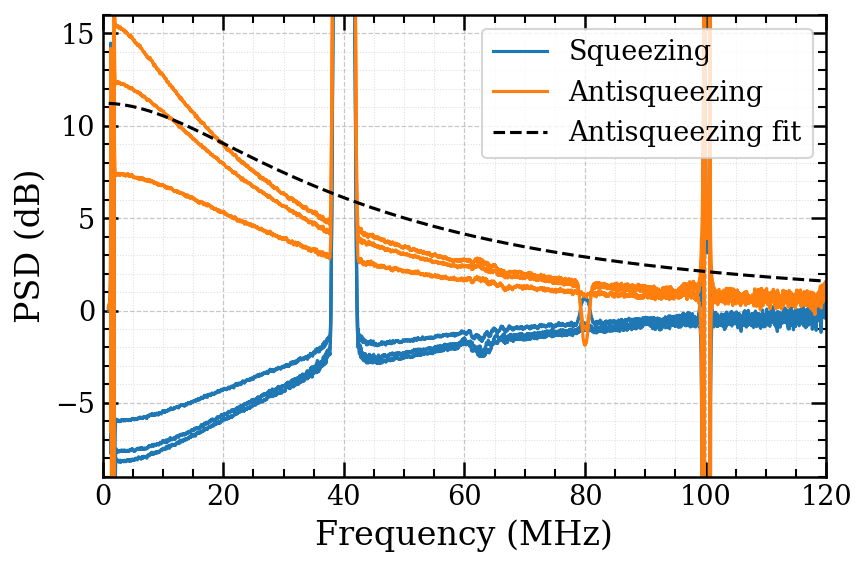

In [180]:
# Create the plot
fig, ax = plt.subplots(figsize=(6, 4))
# Plot data
for sq in squeezing_norm:
    ax.plot(f, sq, c='C0', label='Squeezing')
for asq in antisqueezing_norm:
    ax.plot(f, asq, c='C1', label='Antisqueezing')
# Fit to antisqueezed data and plot
x_fit, eta_fit, bw_fit = res.x
ax.plot(f, lin2db(Vasq(x_fit, eta_fit, f/bw_fit)), 'k--', label='Antisqueezing fit')
# Remove duplicate labels from legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
# Set x- and y-limits
ax.set_xlim(0, 120)
ax.set_ylim(-9, 16)
# Set x- and y-label
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('PSD (dB)')
# Initialize plot settings
PlotSettings(ax, gridlines=True)
# Adjust layout
plt.tight_layout()
# Show the plot
plt.show()

The fit is still very bad, as can be seen visually from the poor fit between data and model (green) and from the very large cost value of the fitting result. The poor fit is due to the strong signals around 40 MHz and 100 MHz and the overtone of the 40 MHz signal at 80 MHz. There's also some nasty stuff at very low frequencies. I therefore create a new mask that removes these frequencies from the data that goes into the fit:

In [181]:
mask = ((f>2) & (f<35)) | ((f>45) & (f<75)) | ((f>85) & (f<95))
len(np.nonzero(mask)[0])

3066

In [182]:
res = least_squares(res_asq, [.5,.8,40], args=[f[mask], test_spec[mask]])
res

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [ 3.661e-01  1.155e-01 ... -3.687e-01 -4.025e-01]
           x: [ 7.463e-01  8.170e-01  3.622e+01]
        cost: 34.818702307540846
         jac: [[-3.744e+01 -5.173e+00 -1.079e-02]
               [-3.740e+01 -5.172e+00 -1.103e-02]
               ...
               [-1.596e+00 -1.383e+00 -6.180e-02]
               [-1.596e+00 -1.382e+00 -6.178e-02]]
        grad: [-7.683e-02 -2.945e-02 -1.016e-03]
  optimality: 0.07682705131780132
 active_mask: [ 0.000e+00  0.000e+00  0.000e+00]
        nfev: 21
        njev: 11

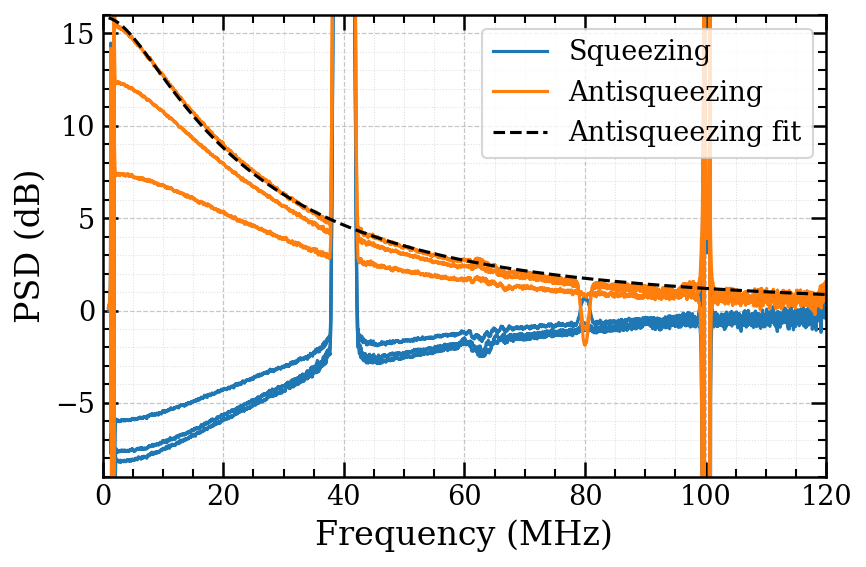

In [183]:
# Create the plot
fig, ax = plt.subplots(figsize=(6, 4))
# Plot data
for sq in squeezing_norm:
    ax.plot(f, sq, c='C0', label='Squeezing')
for asq in antisqueezing_norm:
    ax.plot(f, asq, c='C1', label='Antisqueezing')
# Fit to antisqueezed data and plot
x_fit, eta_fit, bw_fit = res.x
ax.plot(f, lin2db(Vasq(x_fit, eta_fit, f/bw_fit)), 'k--', label='Antisqueezing fit')
# Remove duplicate labels from legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
# Set x- and y-limits
ax.set_xlim(0, 120)
ax.set_ylim(-9, 16)
# Set x- and y-label
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('PSD (dB)')
# Initialize plot settings
PlotSettings(ax, gridlines=True)
# Adjust layout
plt.tight_layout()
# Show the plot
plt.show()

This was a really nice fit! The fitted parameters are in the `x` variable of the fitting result: `[ 7.463e-01  8.170e-01  3.622e+01]`, that is, $x=0.746$, $\eta=0.817$, $f_{HWHM}=36.2\text{ MHz}$.

Could we perhaps make it even better by using the more complex model with phase and phase fluctuation parameters? When adding more parameters, the optimisation problem becomes more ill-defined and "loose", so I will add some bounds to the parameters to help it along.

In [184]:
def res_asq2(params, freq, spec):
    x, eta, bw, theta, sigma = params
    model = lin2db(Vrotfluct(x, eta, freq/bw, theta, sigma))
    residuals = spec - model
    return residuals

In [185]:
res = least_squares(res_asq2, [.5,.8,40, 90, 0], bounds=([0,.5,10,80,0], [.99,1,50,100,10]), args=[f[mask], test_spec[mask]])
res

     message: `xtol` termination condition is satisfied.
     success: True
      status: 3
         fun: [ 3.863e-01  1.357e-01 ... -3.547e-01 -3.885e-01]
           x: [ 7.266e-01  1.000e+00  3.387e+01  1.000e+02  1.000e-10]
        cost: 30.439382717799788
         jac: [[-3.535e+01 -4.225e+00 ...  2.671e-02  0.000e+00]
               [-3.531e+01 -4.225e+00 ...  2.671e-02  0.000e+00]
               ...
               [-1.628e+00 -1.119e+00 ...  1.221e-02  0.000e+00]
               [-1.627e+00 -1.119e+00 ...  1.221e-02  0.000e+00]]
        grad: [ 1.113e-01 -9.634e-01 -2.088e-03 -8.472e-01  0.000e+00]
  optimality: 0.08083992668931403
 active_mask: [ 0  0  0  1 -1]
        nfev: 63
        njev: 58

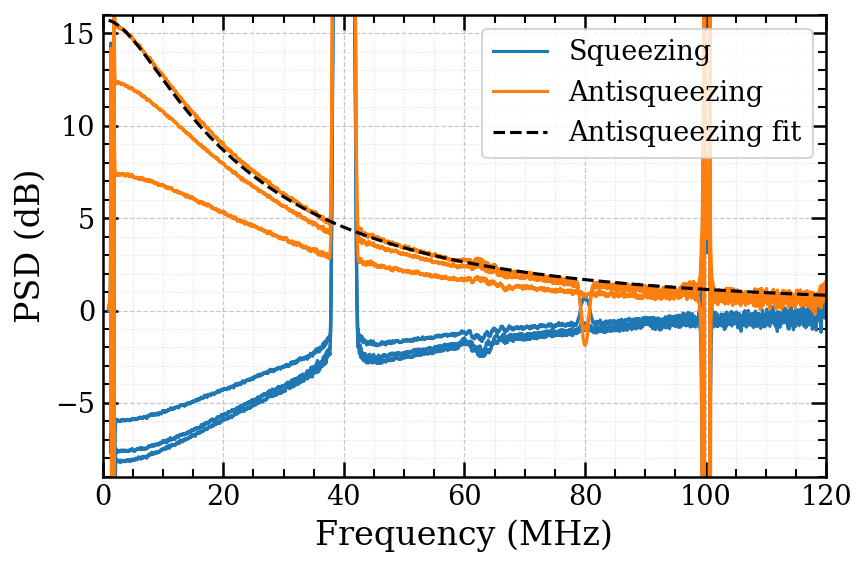

In [186]:
# Create the plot
fig, ax = plt.subplots(figsize=(6, 4))
# Plot data
for sq in squeezing_norm:
    ax.plot(f, sq, c='C0', label='Squeezing')
for asq in antisqueezing_norm:
    ax.plot(f, asq, c='C1', label='Antisqueezing')
# Fit to antisqueezed data and plot
plt.plot(f, lin2db(Vrotfluct(x_fit, eta_fit, f/bw_fit, theta_fit, sigma_fit)),
         'k--', label='Antisqueezing fit')
# Remove duplicate labels from legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
# Set x- and y-limits
ax.set_xlim(0, 120)
ax.set_ylim(-9, 16)
# Set x- and y-label
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('PSD (dB)')
# Initialize plot settings
PlotSettings(ax, gridlines=True)
# Adjust layout
plt.tight_layout()
# Show the plot
plt.show()

This doesn't work very well. The fit looks OK'ish, but two of the parameters (`eta` and `theta`) are hitting their bounds which is a clear indication of a bad fit. Seems to be too many parameters.

Next, I try to fit both the antisqueezing and squeezing for a given power at the same time. Since they're recorded with the same power and same experimental setup, the parameters $x$, $\eta$ and $f_{HWHM}$ should be identical. I also assume $\sigma$ to be identical (not necessarily a good assumption). To fit both curves simultaneously, one can simply concatenate values for both spectra and for both models:

In [187]:
asq_spec = antisqueezing_norm[2]
sq_spec = squeezing_norm[2]

def res_asq3(params, freq, sq_spec, asq_spec):
    x, eta, bw, theta_sq, theta_asq, sigma = params
    sq_model = lin2db(Vrotfluct(x, eta, freq/bw, theta_sq, sigma))
    asq_model = lin2db(Vrotfluct(x, eta, freq/bw, theta_asq, sigma))
    model = np.concatenate([sq_model, asq_model])
    spec = np.concatenate([sq_spec, asq_spec])
    residuals = spec - model
    return residuals

In [188]:
res = least_squares(res_asq3, [.5,.8,40, 0, 90, 0], 
                    bounds=([0,.5,10,-10,80,0], [.99,1,50,10,100,10]), 
                    args=[f[mask], sq_spec[mask], sq_spec[mask]])
res

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [-1.712e+01 -1.233e+01 ... -8.665e-01 -8.805e-01]
           x: [ 1.380e-02  1.000e+00  3.322e+01  1.983e-02  1.000e+02
                1.000e-10]
        cost: 60987.585424590805
         jac: [[ 1.731e+01  2.455e-01 ... -0.000e+00  0.000e+00]
               [ 1.731e+01  2.455e-01 ... -0.000e+00  0.000e+00]
               ...
               [-1.781e+00 -2.450e-02 ...  3.103e-04  0.000e+00]
               [-1.781e+00 -2.449e-02 ...  3.101e-04  0.000e+00]]
        grad: [-1.078e-01 -7.633e+01 -1.978e-02  4.396e-02 -2.108e+01
                0.000e+00]
  optimality: 0.4405207255161677
 active_mask: [ 0  1  0  0  1 -1]
        nfev: 67
        njev: 63

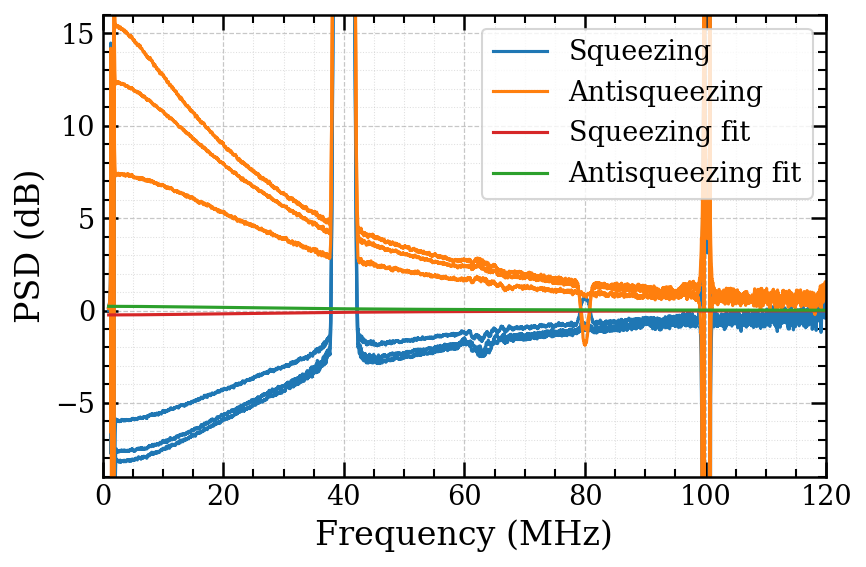

In [189]:
# Create the plot
fig, ax = plt.subplots(figsize=(6, 4))
# Plot data
for sq in squeezing_norm:
    ax.plot(f, sq, c='C0', label='Squeezing')
for asq in antisqueezing_norm:
    ax.plot(f, asq, c='C1', label='Antisqueezing')
# Fit to data and plot
x_fit, eta_fit, bw_fit, theta_sq_fit, theta_asq_fit, sigma_fit = res.x
ax.plot(f, lin2db(Vrotfluct(x_fit, eta_fit, f/bw_fit, theta_sq_fit, sigma_fit)),
        'C3', label='Squeezing fit')
ax.plot(f, lin2db(Vrotfluct(x_fit, eta_fit, f/bw_fit, theta_asq_fit, sigma_fit)),
        'C2', label='Antisqueezing fit')
# Remove duplicate labels from legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
# Set x- and y-limits
ax.set_xlim(0, 120)
ax.set_ylim(-9, 16)
# Set x- and y-label
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('PSD (dB)')
# Initialize plot settings
PlotSettings(ax, gridlines=True)
# Adjust layout
plt.tight_layout()
# Show the plot
plt.show()

That was a very poor fit! Let's try to remove the phase parameters and go back to basics:

In [190]:
asq_spec = antisqueezing_norm[2]  # change index here to switch between the spectra taken at three different powers
sq_spec = squeezing_norm[2]

def res_asq3(params, freq, sq_spec, asq_spec):
    x, eta, bw = params
    sq_model = lin2db(Vrotfluct(x, eta, freq/bw, 0, 0))
    asq_model = lin2db(Vrotfluct(x, eta, freq/bw, 0, 0))
    model = np.concatenate([sq_model, asq_model])
    spec = np.concatenate([sq_spec, asq_spec])
    residuals = spec - model
    return residuals

In [191]:
res = least_squares(res_asq3, [.5,.8,40], 
                    bounds=([0,.5,10], [.99,1,50]), 
                    args=[f[mask], sq_spec[mask], sq_spec[mask]])
res

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [-8.988e+00 -4.205e+00 ...  8.024e-02  6.581e-02]
           x: [ 6.829e-01  8.872e-01  3.028e+01]
        cost: 173.9229214030081
         jac: [[ 7.079e+00  2.872e+01  2.651e-03]
               [ 7.078e+00  2.871e+01  2.713e-03]
               ...
               [ 1.231e+00  1.158e+00  5.269e-02]
               [ 1.231e+00  1.157e+00  5.267e-02]]
        grad: [ 1.013e-04 -6.698e-04  1.483e-05]
  optimality: 0.0003006406655233336
 active_mask: [0 0 0]
        nfev: 6
        njev: 6

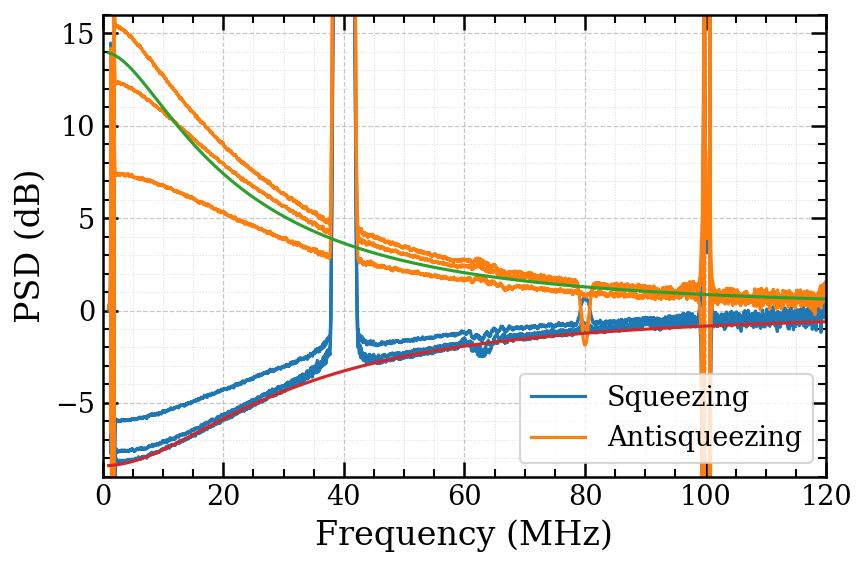

In [192]:
# Create the plot
fig, ax = plt.subplots(figsize=(6, 4))
# Plot data
for sq in squeezing_norm:
    ax.plot(f, sq, c='C0', label='Squeezing')
for asq in antisqueezing_norm:
    ax.plot(f, asq, c='C1', label='Antisqueezing')
# Fit to data and plot
x_fit, eta_fit, bw_fit = res.x
ax.plot(f, lin2db(Vrotfluct(x_fit, eta_fit, f/bw_fit, 0, 0)), 'C3', label='')
ax.plot(f, lin2db(Vrotfluct(x_fit, eta_fit, f/bw_fit, 90, 0)), 'C2')
# Remove duplicate labels from legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
# Set x- and y-limits
ax.set_xlim(0, 120)
ax.set_ylim(-9, 16)
# Set x- and y-label
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('PSD (dB)')
# Initialize plot settings
PlotSettings(ax, gridlines=True)
# Adjust layout
plt.tight_layout()
# Show the plot
plt.show()

The fit works much better now with fewer parameters. Still, for some reason, the dual fit doesn't fit well for the highest-power traces. I suspect there might be an issue with the data, or the model fails to take into account some property of the experiment. The fit for the lowest-power spectra also doesn't look amazing:

In [193]:
asq_spec = antisqueezing_norm[0]
sq_spec = squeezing_norm[0]

def res_asq3(params, freq, sq_spec, asq_spec):
    x, eta, bw = params
    sq_model = lin2db(Vrotfluct(x, eta, freq/bw, 0, 0))
    asq_model = lin2db(Vrotfluct(x, eta, freq/bw, 0, 0))
    model = np.concatenate([sq_model, asq_model])
    spec = np.concatenate([sq_spec, asq_spec])
    residuals = spec - model
    return residuals

In [194]:
res = least_squares(res_asq3, [.5,.8,40], 
                    bounds=([0,.5,10], [.99,1,50]), 
                    args=[f[mask], sq_spec[mask], sq_spec[mask]])
res

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [-3.093e+00 -1.813e+00 ...  1.342e-01  1.071e-01]
           x: [ 4.870e-01  8.612e-01  2.834e+01]
        cost: 48.29788710252245
         jac: [[ 9.622e+00  1.570e+01  2.197e-03]
               [ 9.621e+00  1.570e+01  2.248e-03]
               ...
               [ 1.135e+00  7.192e-01  3.652e-02]
               [ 1.134e+00  7.188e-01  3.651e-02]]
        grad: [-2.477e-04 -1.956e-03  4.976e-05]
  optimality: 0.0009123340122740932
 active_mask: [0 0 0]
        nfev: 6
        njev: 6

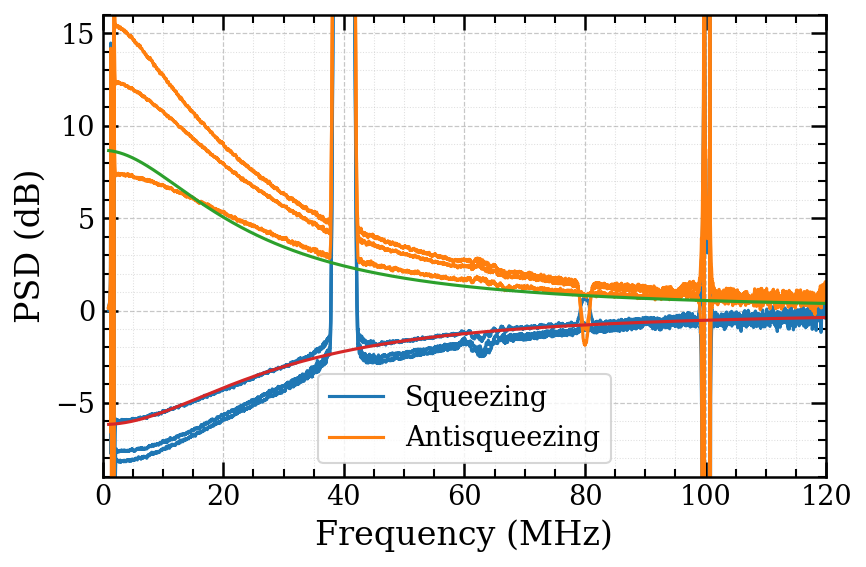

In [195]:
# Create the plot
fig, ax = plt.subplots(figsize=(6, 4))
# Plot data
for sq in squeezing_norm:
    ax.plot(f, sq, c='C0', label='Squeezing')
for asq in antisqueezing_norm:
    ax.plot(f, asq, c='C1', label='Antisqueezing')
# Fit to data and plot
x_fit, eta_fit, bw_fit = res.x
plt.plot(f, lin2db(Vrotfluct(x_fit, eta_fit, f/bw_fit, 0, 0)), 'C3')
plt.plot(f, lin2db(Vrotfluct(x_fit, eta_fit, f/bw_fit, 90, 0)), 'C2')
# Remove duplicate labels from legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
# Set x- and y-limits
ax.set_xlim(0, 120)
ax.set_ylim(-9, 16)
# Set x- and y-label
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('PSD (dB)')
# Initialize plot settings
PlotSettings(ax, gridlines=True)
# Adjust layout
plt.tight_layout()
# Show the plot
plt.show()

However, another issue might be that measurements are a bit unreliable at higher frequencies where the detector efficiency is low (as seen in the first raw spectrum at the top). These have a relatively large weight in the fit and seem to skew the fit in a way that the more accurate low-frequency values don't fit well. 

To test this, below I made a "manual fitting machine" using widgets for the parameters. The default parameters inserted here work quite well for the lowest power spectra -- both squeezing and anti-squeezing -- at low frequencies, while especially the squeezing is somewhat off at higher frequencies. But this looks already much better. When increasing `x` it also somewhat matches the middle-power anti-squeezing and the highest-power squeezing - not what one would expect. It could be that the power labels in the file names are not correct, or (perhaps more likely) that the detector has some saturation at high noise powers.

This manual fitting shows that there is still some massaging to do to make the optimiser give a more realistic fit.

In [196]:
from ipywidgets import interact

@interact(x=(0.,.999,.01), eta=(0.,1.,.01), bw=(10.,100.,1.), 
          theta_sq_offset=(-45.,45.,.1), theta_asq_offset=(-45.,45.,.1), sigma=(0.,10.,.01))
def manual_fit(x=.43, eta=.9, bw=33., theta_sq_offset=0., theta_asq_offset=0., sigma=0.):

    # Create the plot
    fig, ax = plt.subplots(figsize=(6, 4))
    # Plot data
    for sq in squeezing_norm:
        ax.plot(f, sq, c='C0', label='Squeezing')
    for asq in antisqueezing_norm:
        ax.plot(f, asq, c='C1', label='Antisqueezing')
    # Plot
    ax.plot(f, lin2db(Vrotfluct(x, eta, f/bw, 90+theta_asq_offset, sigma)),
            'k--', label='Fit')
    ax.plot(f, lin2db(Vrotfluct(x, eta, f/bw, 0+theta_sq_offset, sigma)),
            'k--', label='Fit')
    # Remove duplicate labels from legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())
    # Set x- and y-limits
    ax.set_xlim(0, 120)
    ax.set_ylim(-9, 16)
    # Set x- and y-label
    ax.set_xlabel('Frequency (MHz)')
    ax.set_ylabel('PSD (dB)')
    # Initialize plot settings
    PlotSettings(ax, gridlines=True)
    # Adjust layout
    plt.tight_layout()
    # Show the plot
    plt.show()

interactive(children=(FloatSlider(value=0.43, description='x', max=0.999, step=0.01), FloatSlider(value=0.9, d…

### Save to HDF5

It is a very good idea to store data in the HDF5 format. It can contain multiple datasets, metadata, attributes on each dataset, and it is quite fast to look into even GB-large files using some of the available HDF5 viewers or e.g. the H5Web extension to VS Code. Here we format the metadata from one of the traces (using `dtype='S'` as the default `'U'` datatype for NumPy string arrays does not work) and place it in a single .hdf5 file together with all the spectra extracted from the CSV files.

In [147]:
meta_elec = np.genfromtxt(elec_spec_file, delimiter=',', skip_header=2, max_rows=42, dtype='S')
meta_elec

array([[b'A.18.12', b'N9000A'],
       [b'503 ', b'01'],
       [b'Segment', b'0'],
       [b'Number of Points', b'5000'],
       [b'Sweep Time', b'0.889488733333'],
       [b'Start Frequency', b'1000000'],
       [b'Stop Frequency', b'120000000'],
       [b'Average Count', b'0'],
       [b'Average Type', b'LogPower(Video)'],
       [b'RBW', b'1100000'],
       [b'RBW Filter', b'Gaussian'],
       [b'RBW Filter BW', b'3dB'],
       [b'VBW', b'300'],
       [b'Sweep Type', b'Swept'],
       [b'X Axis Scale', b'Lin'],
       [b'PreAmp State', b'Off'],
       [b'PreAmp Band', b'Low'],
       [b'Trigger Source', b'Free'],
       [b'Trigger Level', b'1.2'],
       [b'Trigger Slope', b'Positive'],
       [b'Trigger Delay', b'0'],
       [b'Phase Noise Optimization', b'Fast'],
       [b'Swept If Gain', b'Low'],
       [b'FFT If Gain', b'Autorange'],
       [b'RF Coupling', b'AC'],
       [b'FFT Width', b'411900'],
       [b'Ext Ref', b'10000000'],
       [b'Input', b'RF'],
       [b'RF Calibr

In [148]:
meta_elec = {a[0]:a[1] for a in meta_elec}
meta_elec

{np.bytes_(b'A.18.12'): np.bytes_(b'N9000A'),
 np.bytes_(b'503 '): np.bytes_(b'01'),
 np.bytes_(b'Segment'): np.bytes_(b'0'),
 np.bytes_(b'Number of Points'): np.bytes_(b'5000'),
 np.bytes_(b'Sweep Time'): np.bytes_(b'0.889488733333'),
 np.bytes_(b'Start Frequency'): np.bytes_(b'1000000'),
 np.bytes_(b'Stop Frequency'): np.bytes_(b'120000000'),
 np.bytes_(b'Average Count'): np.bytes_(b'0'),
 np.bytes_(b'Average Type'): np.bytes_(b'LogPower(Video)'),
 np.bytes_(b'RBW'): np.bytes_(b'1100000'),
 np.bytes_(b'RBW Filter'): np.bytes_(b'Gaussian'),
 np.bytes_(b'RBW Filter BW'): np.bytes_(b'3dB'),
 np.bytes_(b'VBW'): np.bytes_(b'300'),
 np.bytes_(b'Sweep Type'): np.bytes_(b'Swept'),
 np.bytes_(b'X Axis Scale'): np.bytes_(b'Lin'),
 np.bytes_(b'PreAmp State'): np.bytes_(b'Off'),
 np.bytes_(b'PreAmp Band'): np.bytes_(b'Low'),
 np.bytes_(b'Trigger Source'): np.bytes_(b'Free'),
 np.bytes_(b'Trigger Level'): np.bytes_(b'1.2'),
 np.bytes_(b'Trigger Slope'): np.bytes_(b'Positive'),
 np.bytes_(b'Trigge

In [149]:
with h5py.File('squeezing_data.hdf5', 'w') as file:
    dset_spec = file.create_group('spectrum')
    dset_freq = dset_spec.create_dataset('frequencies', data=f)
    dset_elec = dset_spec.create_dataset('electronic', data=electronic)
    dset_vac = dset_spec.create_dataset('vacuum', data=vacuum)
    dset_sqz = dset_spec.create_dataset('squeezing', data=squeezing)
    dset_asqz = dset_spec.create_dataset('antisqueezing', data=antisqueezing)
    for key, val in meta_elec.items():
        dset_spec.attrs[key] = val

The data can also be compressed:

In [150]:
with h5py.File('squeezing_data_zipped.hdf5', 'w') as file:
    dset_spec = file.create_group('spectrum')
    dset_freq = dset_spec.create_dataset('frequencies', data=f, chunks=True, compression='gzip')
    dset_elec = dset_spec.create_dataset('electronic', data=electronic, chunks=True, compression='gzip')
    dset_vac = dset_spec.create_dataset('vacuum', data=vacuum, chunks=True, compression='gzip')
    dset_sqz = dset_spec.create_dataset('squeezing', data=squeezing, chunks=True, compression='gzip')
    dset_asqz = dset_spec.create_dataset('antisqueezing', data=antisqueezing, chunks=True, compression='gzip')
    for key, val in meta_elec.items():
        dset_spec.attrs[key] = val

Reading HDF5 files is also easy - just access it like a file system:

In [151]:
file = h5py.File('squeezing_data_zipped.hdf5', 'r')
list(file.keys())

['spectrum']

In [152]:
list(file['spectrum'].keys())

['antisqueezing', 'electronic', 'frequencies', 'squeezing', 'vacuum']

In [153]:
spec = file['spectrum']
spec['frequencies'][:]

array([  1.        ,   1.02380476,   1.04760952, ..., 119.95239048,
       119.97619524, 120.        ], shape=(5000,))

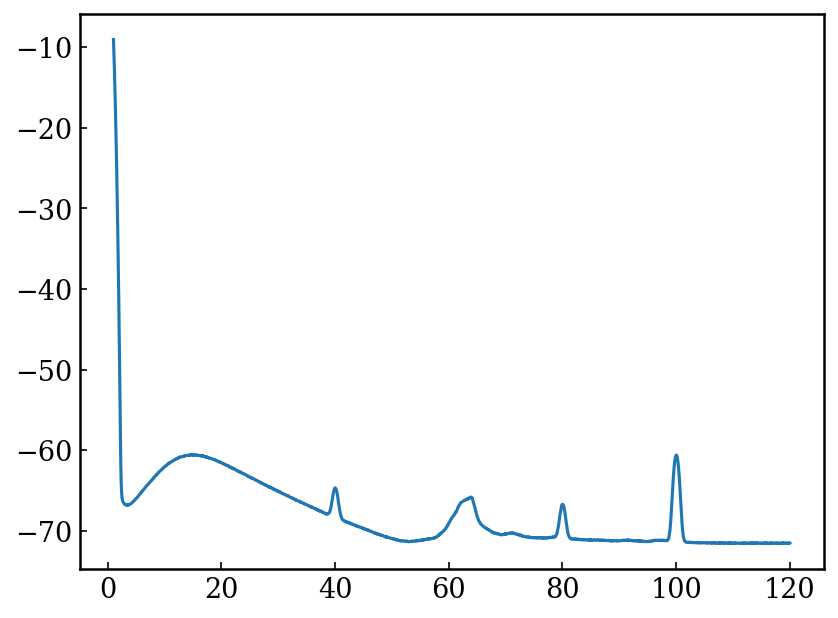

In [154]:
spec = file['spectrum']
plt.plot(spec['frequencies'][:], spec['electronic'][:])
file.close()

## Xueshi data

Below I give just the minimum necessary code to load Xueshi's data files. Then it's your turn to play around with it.

LeCroy's binary file format is described on pages 190—192 of [this reference document](https://cdn.teledynelecroy.com/files/manuals/maui-remote-control-and-automation-manual.pdf) and is implemented in [lecroy.py](https://github.com/qpit/jonas-qopt/blob/master/qopt/lecroy.py).

In [155]:
datasets = ['electronic', 'shotnoise', 'squeezing', 'antisqueezing']
channels = ['C1', 'C2', 'C3', 'C4']

def get_file_list(dataset, channel):
    folder = os.path.join(xueshi_folder, dataset, channel)
    fns = sorted(os.listdir(folder))
    fns = [os.path.join(folder, fn) for fn in fns]
    return fns

files = {ds:
           {ch:get_file_list(ds, ch) for ch in channels}
           for ds in datasets}

In [156]:
meta, times, data = lecroy.read(files['shotnoise']['C1'][0], scale=False)
dt = meta['horiz_interval']
fs = 1/dt
N = len(data[0])
t = np.linspace(0, dt*N, N, endpoint=False)
f = rfftfreq(N, dt)
# meta

In [157]:
meta

{'descriptor_name': b'WAVEDESC',
 'template_name': b'LECROY_2_3',
 'comm_type': 1,
 'comm_order': 1,
 'wave_descriptor': 346,
 'user_text': 0,
 'res_desc1': 0,
 'trig_time_array': 0,
 'ris_time_array': 0,
 'res_array1': 0,
 'wave_array1': 200004,
 'wave_array2': 0,
 'res_array2': 0,
 'res_array3': 0,
 'instrument_name': b'LECROYHDO6034',
 'instrument_number': 6034,
 'trace_label': b'',
 'reserved1': -31070,
 'reserved2': 1,
 'wave_array_count': 100002,
 'points_per_screen': 100000,
 'first_valid_point': 0,
 'last_valid_point': 100001,
 'first_point': 0,
 'sparsing_factor': 1,
 'segment_index': 0,
 'subarray_count': 1,
 'sweeps_per_acq': 1,
 'points_per_pair': 0,
 'pair_offset': 0,
 'vertical_gain': 1.249999968422344e-05,
 'vertical_offset': -0.0,
 'max_value': 31744.0,
 'min_value': -32000.0,
 'nominal_bits': 12,
 'nom_subarray_count': 1,
 'horiz_interval': 1.999999943436137e-09,
 'horiz_offset': -0.00010000060683430235,
 'pixel_offset': -9.999999999999999e-05,
 'vert_unit': b'V',
 'ho

In [158]:
for ds in datasets:
    data = np.array([[
        lecroy.read(f, scale=False)[2] for f in files[ds][ch]]
                     for ch in channels])
    data = data.squeeze()  # not optical squeezing!
    globals()[ds] = data


In [159]:
electronic.shape, shotnoise.shape, squeezing.shape, antisqueezing.shape

((4, 200, 100002), (4, 200, 100002), (4, 200, 100002), (4, 200, 100002))

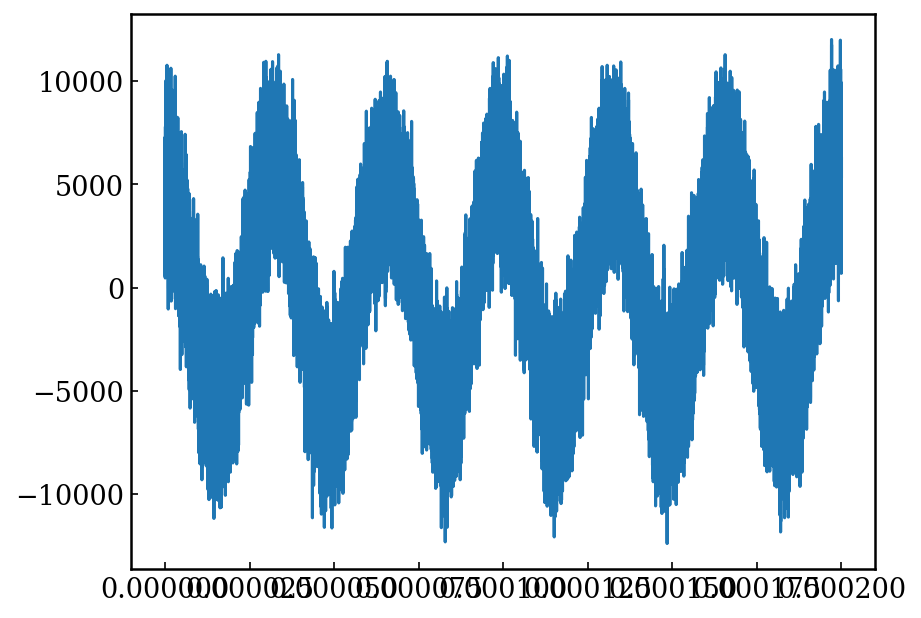

In [160]:
plt.plot(t, antisqueezing[0,0])

(0.0, 50000000.0)

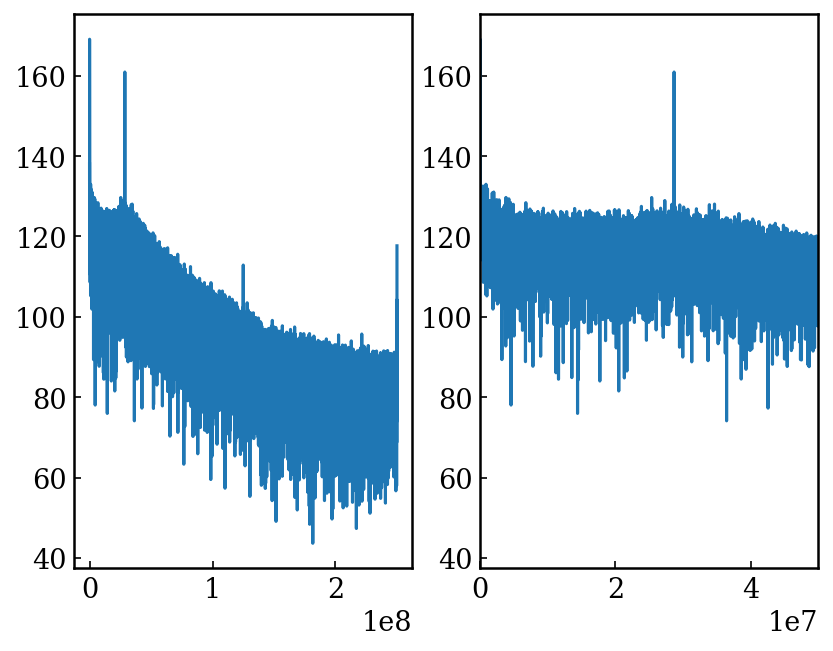

In [161]:
fig, axs = plt.subplots(1, 2)
spec = np.fft.rfft(antisqueezing[0,0])
psd = 10*np.log10(np.abs(spec)**2)
axs[0].plot(f, psd)
axs[1].plot(f, psd)
axs[1].set_xlim(0, 50e6)

In [162]:
peaks = sp.signal.find_peaks(psd, height=125, threshold=5, distance=1000)
peaks

(array([   6, 1356, 2799, 3991, 5740, 6935]),
 {'peak_heights': array([169.08971703, 128.41132191, 126.96628427, 126.62119146,
         160.92969359, 128.06615208]),
  'left_thresholds': array([41.55830121, 13.32436728, 12.50856953, 17.91132912, 19.63902268,
         12.43318005]),
  'right_thresholds': array([46.43372417,  9.09477364,  8.80839254,  5.40745724, 18.73485261,
         15.26690385])})

In [163]:
f[peaks[0]] / 1e6

array([2.99994009e-02, 6.77986459e+00, 1.39947205e+01, 1.99546015e+01,
       2.86994268e+01, 3.46743075e+01])